# 61 · Gulf of Trieste map design

A plotting workspace for the spatial figure in **plot_design_report_gulf_of_trieste.pdf**, section 1 (with the caption guidance in section 3), updated using **2_gulf_of_trieste_map_todo.pdf**.

**(a) Observed AIS counts → (b) Predicted mean AIS counts → (c) Prediction residuals (predicted − observed).**

This notebook reads the saved final predictions from the **seed 1 LGCP confidence-redistribution** weekly experiments for May and November 2025. It does not train models, run inference, or load the full training dataset. The preview day is controlled by `DATE` below; it is an editable design example, not a claim that this is the most representative day.

**Working loop**
1. Run all cells once to load the saved data and see the initial figure.
2. For colours, labels, sizing, or support markers, edit **Style and preview** and rerun that cell only.
3. For a different model/day or interpolation, edit **Select data and prepare surfaces**, then rerun it and the preview.
4. Enable **Export** when ready to save PNG/PDF/SVG, the source cell values, settings, and caption.

Land/coastline context now comes from Eurostat GISCO geometry; the coloured model support is separately derived from retained cells. All design-specific code stays here while we iterate. The existing grid-surface helper is reused unchanged. The PDF's secondary agreement/hexbin plot is outside this notebook's scope.

## Setup
Run from the repository root or `notebooks/`. Saved predictions and the small bundled GIS/grid snapshots are sufficient; no model execution, full training dataset, network connection, or runtime PDF access is needed.

In [17]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import json
import sys
import yaml

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, FuncNorm
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Patch
from matplotlib.lines import Line2D
import geopandas as gpd
import shapely
from shapely.geometry import box, Point
from shapely.geometry.polygon import orient
from scipy.spatial import cKDTree
from pyproj import Transformer
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "src/visualization/grid_surface.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from the AIPS repository root or notebooks/.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.visualization.grid_surface import complete_grid_surface

EXPERIMENT_ROOT = PROJECT_ROOT / "reports/seeded_monthly_windows_salinity_oldclassifier/11_train_lgcp"
SEED_DIR = EXPERIMENT_ROOT / "seed_1"
ASSET_DIR = PROJECT_ROOT / "notebooks/assets/map_design_61"
GIS_FILE = ASSET_DIR / "gisco_2024_01m_gulf_countries.geojson"
GRID_FILE = ASSET_DIR / "retained_grid_centres.csv"
MARITIME_FILE = ASSET_DIR / "marine_regions_gulf_boundaries.geojson"
SLOVENIAN_WATERS_FILE = ASSET_DIR / "marine_regions_slovenian_waters.geojson"
CROATIAN_WATERS_FILE = ASSET_DIR / "marine_regions_croatian_waters.geojson"
ITALIAN_WATERS_FILE = ASSET_DIR / "marine_regions_italian_waters.geojson"
MARITIME_SOURCE = json.loads((ASSET_DIR / "maritime_sources.json").read_text())
GEOGRAPHY_SOURCE = json.loads((ASSET_DIR / "sources.json").read_text())
retained_grid = pd.read_csv(GRID_FILE)
if retained_grid.duplicated(["longitude", "latitude"]).any() or not np.isfinite(retained_grid.to_numpy()).all():
    raise ValueError("The retained-grid snapshot must contain unique finite centres.")
grid_tree = cKDTree(retained_grid[["longitude", "latitude"]].to_numpy())
EXPORT_DIR = PROJECT_ROOT / "reports/paper/map_design_61"
METHOD_LABELS = {"lgcp": "LGCP (confidence redistribution)"}

## Load saved weekly values once
Read the windows from `seed_1/manifest.yaml` and load each run's `spatial_predictions.csv` under `seed_1/runs/`. These files contain the **final predictions after confidence redistribution**, so no checkpoint loading or inference is needed. The run's `params.yaml` must match the manifest window, seed 1, and the `fixed_test_window` split (training dates strictly before the window starts).

The available windows are **1–7, 8–14, 15–21, and 22–28** in both **May and November 2025**. Set `DATE` below to any of these **56 days**; its weekly run is selected automatically. **May 29–31 and November 29–30 are not covered by these experiments** and raise an error. They require additional runs trained through the 28th, rather than reusing an earlier week's model.

Saved standardized coordinates are inverted with their plotting metadata, then matched to the **original retained cell centres** in the local grid snapshot within 0.0001 degrees. Counts and final predictions are unchanged. Missing dates/cells, overlapping windows and ambiguous run directories are rejected.

The weekly inventory shows each prediction window, its training cutoff and source run. The daily inventory reports cell totals. Source paths and window metadata are retained in the cell data and exports.


In [18]:
required = {"date", "x", "y", "observed", "predicted",
            "lon_mean", "lon_std", "lat_mean", "lat_std"}
manifest = yaml.safe_load((SEED_DIR / "manifest.yaml").read_text())
if not isinstance(manifest, list) or not manifest:
    raise ValueError("The seed manifest must contain prediction windows.")
source_files = []
frames = []
windows = []
for window in manifest:
    period = window["month"]
    start = pd.Timestamp(window["test_start_date"]).normalize()
    end = pd.Timestamp(window["test_end_date"]).normalize()
    if pd.isna(start) or pd.isna(end) or start > end:
        raise ValueError(f"Invalid prediction window: {window}")
    if start.year != 2025 or start.month not in (5, 11) or start.to_period("M") != end.to_period("M"):
        raise ValueError(f"Expected a window within May or November 2025: {window}")
    candidates = sorted((SEED_DIR / "runs" / window["name"]).glob("*/spatial_predictions.csv"))
    if len(candidates) != 1:
        raise ValueError(f"{window['name']}: expected exactly one saved run, found {len(candidates)} in {SEED_DIR / 'runs' / window['name']}")
    run_dir = candidates[0].parent
    params = yaml.safe_load((run_dir / "params.yaml").read_text())
    if (params.get("split_strategy") != "fixed_test_window"
            or params.get("np_seed") != 1 or params.get("data_seed") != 1
            or pd.Timestamp(params.get("test_start_date")) != start
            or pd.Timestamp(params.get("test_end_date")) != end):
        raise ValueError(f"{run_dir}: run parameters do not match the seed/window.")
    gate = params.get("zero_gate") or {}
    if not gate.get("enabled") or gate.get("mode") != "confidence_redistribute":
        raise ValueError(f"{run_dir}: expected final confidence-redistribution predictions.")
    train_end = (start - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    windows.append(dict(window=window["name"], period=period,
                        test_start=start, test_end=end, train_end=train_end,
                        source_run=run_dir.name))
    path = run_dir / "spatial_predictions.csv"
    if not path.is_file():
        raise FileNotFoundError(f"Missing saved predictions: {path}")
    saved = pd.read_csv(path)
    missing = required - set(saved.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")
    if saved.empty:
        raise ValueError(f"{path}: no saved prediction rows")
    saved["date"] = pd.to_datetime(saved["date"], errors="raise").dt.normalize()
    expected_days = pd.date_range(start, end, freq="D")
    actual_days = pd.DatetimeIndex(saved["date"].unique()).sort_values()
    if saved["date"].isna().any() or not actual_days.equals(expected_days):
        raise ValueError(f"{path}: saved dates do not exactly cover {start.date()} through {end.date()}")
    if not saved.groupby("date").size().eq(len(retained_grid)).all():
        raise ValueError(f"{path}: each day must cover all retained cells")
    numeric = sorted(required - {"date"})
    saved[numeric] = saved[numeric].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(saved[numeric].to_numpy()).all():
        raise ValueError(f"{path}: nonfinite coordinates, counts, or metadata")
    if (saved[["lon_std", "lat_std"]] <= 0).any().any():
        raise ValueError(f"{path}: coordinate scales must be positive")
    if (saved[["lon_mean", "lon_std", "lat_mean", "lat_std"]].nunique() != 1).any():
        raise ValueError(f"{path}: inconsistent coordinate metadata within one run")
    frame = saved.rename(columns={"observed": "y_true", "predicted": "y_pred"}).copy()
    frame["longitude"] = frame["x"] * frame["lon_std"] + frame["lon_mean"]
    frame["latitude"] = frame["y"] * frame["lat_std"] + frame["lat_mean"]
    # Legacy saved plotting metadata differs slightly from the training scaler.
    # Match to the original grid with a strict tolerance; never move a count to a different cell.
    approximate = frame[["longitude", "latitude"]].to_numpy()
    distances, indices = grid_tree.query(approximate)
    if distances.max() > 0.0001:
        raise ValueError(f"{path}: saved positions do not match the original retained grid within 0.0001 degrees")
    frame["longitude_saved_plot"] = frame["longitude"]
    frame["latitude_saved_plot"] = frame["latitude"]
    frame[["longitude", "latitude"]] = retained_grid.iloc[indices][["longitude", "latitude"]].to_numpy()
    frame["method"] = "lgcp"
    frame["period"] = period
    frame["source_window"] = window["name"]
    frame["test_start"] = start.strftime("%Y-%m-%d")
    frame["test_end"] = end.strftime("%Y-%m-%d")
    frame["train_end"] = train_end
    frame["seed"] = 1
    frame["source_run"] = run_dir.name
    frame["source_csv"] = str(path.relative_to(PROJECT_ROOT))
    frames.append(frame)
    source_files.append(path)

predictions = pd.concat(frames, ignore_index=True)
predictions["date"] = pd.to_datetime(predictions["date"], errors="raise").dt.normalize()
if predictions[["method", "date"]].isna().any().any():
    raise ValueError("Every saved row needs a model and date.")
numeric_columns = ["longitude", "latitude", "y_true", "y_pred"]
predictions[numeric_columns] = predictions[numeric_columns].apply(pd.to_numeric, errors="raise")
if not np.isfinite(predictions[numeric_columns].to_numpy()).all():
    raise ValueError("Coordinates and counts must be finite.")
if (predictions[["y_true", "y_pred"]] < 0).any().any():
    raise ValueError("Observed and predicted counts must be nonnegative.")
cell_key = ["method", "date", "longitude", "latitude"]
if predictions.duplicated(cell_key).any():
    raise ValueError("Duplicate model/date/cell rows: resolve overlapping exports before plotting.")

window_inventory = pd.DataFrame(windows).sort_values("test_start").reset_index(drop=True)
for previous, current in zip(window_inventory.itertuples(), window_inventory.iloc[1:].itertuples()):
    if current.test_start <= previous.test_end:
        raise ValueError("Prediction windows overlap; each date must identify exactly one run.")
AVAILABLE_DATES = predictions["date"].drop_duplicates().sort_values().dt.strftime("%Y-%m-%d").tolist()
display(window_inventory)
inventory = predictions.groupby(["period", "method", "date"]).agg(
    cells=("y_true", "size"), observed_total=("y_true", "sum"),
    predicted_total=("y_pred", "sum"),
).reset_index()
display(inventory)
print(f"Loaded {len(source_files)} weekly runs, {len(AVAILABLE_DATES)} selectable days, {len(predictions):,} cell-day rows.")

,window,period,test_start,test_end,train_end,source_run
0,2025_may_01_07,may,2025-05-01,2025-05-07,2025-04-30,2024+2025_2025_may_01_07_20261002-093859
1,2025_may_08_14,may,2025-05-08,2025-05-14,2025-05-07,2024+2025_2025_may_08_14_20261002-095215
2,2025_may_15_21,may,2025-05-15,2025-05-21,2025-05-14,2024+2025_2025_may_15_21_20261002-100441
3,2025_may_22_28,may,2025-05-22,2025-05-28,2025-05-21,2024+2025_2025_may_22_28_20261002-101508
4,2025_november_01_07,november,2025-11-01,2025-11-07,2025-10-31,2024+2025_2025_november_01_07_20261002-102826
5,2025_november_08_14,november,2025-11-08,2025-11-14,2025-11-07,2024+2025_2025_november_08_14_20261002-103856
6,2025_november_15_21,november,2025-11-15,2025-11-21,2025-11-14,2024+2025_2025_november_15_21_20261002-105011
7,2025_november_22_28,november,2025-11-22,2025-11-28,2025-11-21,2024+2025_2025_november_22_28_20261002-110426


,period,method,date,cells,observed_total,predicted_total
0,may,lgcp,2025-05-01,49,2,0.742768
1,may,lgcp,2025-05-02,49,13,4.794676
2,may,lgcp,2025-05-03,49,0,0.554684
3,may,lgcp,2025-05-04,49,0,0.711598
4,may,lgcp,2025-05-05,49,0,16.158689
5,may,lgcp,2025-05-06,49,19,14.376250
6,may,lgcp,2025-05-07,49,37,14.877958
7,may,lgcp,2025-05-08,49,32,16.682589
8,may,lgcp,2025-05-09,49,28,13.862430
9,may,lgcp,2025-05-10,49,0,0.429200


Loaded 8 weekly runs, 56 selectable days, 2,744 cell-day rows.


## Geographic context and model support

The bundled land polygons come from [Eurostat GISCO Countries 2024, 1:1 million](https://gisco-services.ec.europa.eu/distribution/v2/countries/countries-2024-units.html). GeoPandas clips the local Italy/Slovenia/Croatia subset to the shared extent below. Sources, checksums and reproduction notes are in `notebooks/assets/map_design_61/`. Export captions include the source credit: **© EuroGeographics for the administrative boundaries**. GISCO requests that credit on the publication's introductory page too; see the [source's use conditions](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units).

The support footprint is the union of one rectangular grid cell around every original retained centre (half a grid spacing on each side), intersected with water. This is a transparent **display-support convention**, not a coastline or a national/maritime jurisdiction. The grid snapshot is identical in the 2024 and 2025 processed datasets. GISCO country boundaries are drawn on land only; a separate published maritime layer supplies sea divisions. Labels identify Italy and Slovenia explicitly; water outside retained support matches the darkest colour of the count grid. It is background only, not an inferred zero count; the dashed edge still identifies model coverage.

The GIS layer is generalized geographic context, so finer harbour or coastal details may require a higher-resolution coastline in a later iteration. The current study-area polygon is not treated as authoritative coast geometry.

A coarse coastal cell can have its centre on GIS land (one of the 49 centres in this subset). Its original counts and cell footprint are retained; only the water part can be coloured. The `show_support=True` overlay exposes this alignment directly.

The western and southern map limits are computed from the leftmost and lowest retained cell edges (centre minus half a grid spacing), aligning the vertical and horizontal axes with the model grid.

The optional **maritime lines** come from [Marine Regions / VLIZ, v12](https://www.marineregions.org/downloads.php) ([CC BY](https://www.marineregions.org/disclaimer.php)); `maritime_sources.json` records the exact request and feature IDs. Italy's two bilateral lines are classified as treaty boundaries. The dashed Slovenia–Croatia line follows the [2017 arbitral award](https://pca-cpa.org/en/cases/3/), which [Croatia does not accept](https://mvep.gov.hr/pm-plenkovic-arbitral-award-does-not-in-any-way-bind-croatia-and-croatia-shall-not-implement-it/195887). The map identifies this distinction rather than presenting all lines as agreed boundaries. Joint-regime limits and straight baselines are omitted. No lines are inferred, extended or geometrically smoothed; soft styling changes their appearance only.


The Slovenian-water display mask uses the same provider’s [Slovenia polygon, MRGID 5692](https://www.marineregions.org/eezdetails.php?mrgid=5692), intersected with GIS water. It is bundled locally with its source request and checksum. The original retained-support mask is preserved separately, so the exclusion can be toggled without recomputing or changing predictions.

In [19]:
# One common geographic context for every day, model panel, and interval preview.
COUNTRY_LABELS = {"Italy": (13.35, 45.79), "Slovenia": (13.81, 45.57), "Croatia": (13.70, 45.45)}
SUPPORT_NOTE = ("Model values are shown only over retained support; "
                "sea outside it is background, not a zero-valued prediction.")


def grid_axis(values):
    unique = np.unique(np.asarray(values, dtype=float))
    if len(unique) < 2:
        raise ValueError("At least two retained coordinates per axis are required.")
    indices = np.rint((unique - unique[0]) / np.diff(unique).min()).astype(int)
    step = (unique[-1] - unique[0]) / indices[-1]
    if not np.allclose(unique, unique[0] + indices * step, atol=step * 0.002, rtol=0):
        raise ValueError("Retained cell centres must belong to a regular grid.")
    edges = unique[0] - step / 2 + np.arange(indices[-1] + 2) * step
    return unique[0], step, edges


# Align both axes to the outer western and southern cell edges, not the cell centres.
GRID_WEST = float(grid_axis(retained_grid.longitude)[2][0])
GRID_SOUTH = float(grid_axis(retained_grid.latitude)[2][0])
# west, south, east, north; lies within the bundled GIS subset.
MAP_EXTENT = (GRID_WEST, GRID_SOUTH, 13.90, 45.84)


def make_geography(grid, extent):
    west, south, east, north = extent
    if not (west < east and south < north):
        raise ValueError("MAP_EXTENT must be (west, south, east, north).")
    available = box(*GEOGRAPHY_SOURCE["clip_bounds_west_south_east_north"])
    view = box(*extent)
    if not available.covers(view):
        raise ValueError("MAP_EXTENT exceeds the bundled GIS subset; obtain a wider subset first.")
    countries = gpd.clip(gpd.read_file(GIS_FILE).to_crs(4326), view)
    land = countries.geometry.union_all()
    water = view.difference(land)
    slovenian_waters = gpd.read_file(SLOVENIAN_WATERS_FILE).to_crs(4326).geometry.union_all().intersection(water)
    croatian_waters = gpd.read_file(CROATIAN_WATERS_FILE).to_crs(4326).geometry.union_all().intersection(water)
    italian_waters = gpd.read_file(ITALIAN_WATERS_FILE).to_crs(4326).geometry.union_all().intersection(water)
    maritime_lines = gpd.read_file(MARITIME_FILE).to_crs(4326)
    maritime_lines["geometry"] = maritime_lines.geometry.intersection(water)
    maritime_lines = maritime_lines.loc[~maritime_lines.geometry.is_empty].copy()
    x0, dx, xe = grid_axis(grid.longitude)
    y0, dy, ye = grid_axis(grid.latitude)
    ix = np.rint((grid.longitude.to_numpy() - x0) / dx).astype(int)
    iy = np.rint((grid.latitude.to_numpy() - y0) / dy).astype(int)
    # Shared edges avoid tiny artificial gaps from floating-point coordinate rounding.
    footprints = shapely.union_all([
        box(xe[i], ye[j], xe[i + 1], ye[j + 1]) for i, j in zip(ix, iy)
    ])
    support = footprints.intersection(water)
    if support.is_empty:
        raise ValueError("No retained model support intersects water in this extent.")
    national_lines = []
    geoms = countries.geometry.tolist()
    for i, a in enumerate(geoms):
        for b in geoms[i + 1:]:
            line = a.boundary.intersection(b.boundary)
            if line.length > 0:
                national_lines.append(line)
    return dict(
        extent=tuple(extent), countries=countries, land=land, water=water,
        footprints=footprints, support=support,
        slovenian_waters=slovenian_waters, croatian_waters=croatian_waters, italian_waters=italian_waters,
        support_without_slovenia=support.difference(slovenian_waters),
        # Remove artificial edges introduced by clipping the GIS layer to the frame.
        coastline=land.boundary.difference(view.boundary),
        national_borders=shapely.union_all(national_lines),
        maritime_lines=maritime_lines,
        support_edge=footprints.boundary.intersection(water).difference(view.boundary),
        grid=grid.copy(), cell_spacing=(dx, dy),
    )


geography = make_geography(retained_grid, MAP_EXTENT)
land_centres = shapely.intersects_xy(geography["land"], retained_grid.longitude, retained_grid.latitude)
print(f"GIS context: Eurostat GISCO {GEOGRAPHY_SOURCE['version']}; {len(retained_grid)} retained centres.")
print(f"Retained centres falling on GIS land: {int(land_centres.sum())}; land pixels are always masked.")
print("Display support = retained cell footprints intersected with water; maritime context uses published source lines.")

GIS context: Eurostat GISCO 2024; 49 retained centres.
Retained centres falling on GIS land: 1; land pixels are always masked.
Display support = retained cell footprints intersected with water; maritime context uses published source lines.


## Surface preparation and figure helpers

The existing **complete-grid diffusion + PCHIP display interpolation** remains unchanged. Its temporary zero-filled rectangular grid is only an interpolation device. After interpolation, a common mask limits all fields to **retained grid-cell footprints intersected with GIS water**. Unsupported raster pixels are transparent and reveal the dark sea background, not a zero-valued prediction. The raster also receives an exact vector clip, and the GIS land layer covers any coastal pixel fringes.

The model-support edge is shown as a subtle dashed line, clearly distinct from the solid GIS coastline. The southwest sea stays visible outside this edge, as do the Slovenian coast and unsupported water. The old hand-drawn Gulf polygon is no longer used. No maritime boundary is inferred.

All panels use exactly the same extent, grid, mask and local geographic aspect ratio. Residuals remain **the displayed predicted surface minus the displayed observed surface**; since PCHIP is nonlinear, this need not equal an independently interpolated raw-residual field. Exported residuals and all metrics use the raw retained-cell counts.

Observed and predicted maps share one colour scale. Automatic residual limits are ± the maximum absolute displayed residual (±1 only for the identically zero case); `residual_vmax` can set a larger symmetric range. These are counts per retained location-day, not continuous vessel density. To inspect alignment, enable `show_support=True` in the preview style to overlay the original retained grid centres.

In [20]:
def geometry_clip_patch(geometry, transform):
    """Vector clip with correctly oriented exterior rings and holes."""
    polygons = [geometry] if geometry.geom_type == "Polygon" else list(geometry.geoms)
    paths = []
    for polygon in polygons:
        polygon = orient(polygon, sign=1.0)
        for ring in [polygon.exterior, *polygon.interiors]:
            vertices = np.asarray(ring.coords)
            codes = np.full(len(vertices), MplPath.LINETO, dtype=np.uint8)
            codes[0], codes[-1] = MplPath.MOVETO, MplPath.CLOSEPOLY
            paths.append(MplPath(vertices, codes))
    return PathPatch(MplPath.make_compound_path(*paths), transform=transform)


def prepare_map(data, geography, method, date, *, nx=900, ny=600,
                radius_cells=1, diffusion_strength=0.25, display_method="pchip"):
    selected_date = pd.Timestamp(date).normalize()
    rows = data.loc[(data["method"] == method) & (data["date"] == selected_date)].copy()
    if rows.empty:
        available = data.loc[data["method"] == method, "date"].dt.strftime("%Y-%m-%d").unique()
        raise ValueError(f"No saved values for {method} on {date}. Available dates: {sorted(available)}")
    if not isinstance(nx, int) or not isinstance(ny, int) or min(nx, ny) < 2:
        raise ValueError("nx and ny must be integers of at least 2.")
    rows = rows.sort_values(["latitude", "longitude"]).reset_index(drop=True)
    expected = geography["grid"].sort_values(["latitude", "longitude"])
    if len(rows) != len(expected) or not np.allclose(
        rows[["longitude", "latitude"]], expected[["longitude", "latitude"]], atol=1e-10, rtol=0
    ):
        raise ValueError("Selected values must cover exactly the retained grid used for the support mask.")
    rows["residual"] = rows["y_pred"] - rows["y_true"]
    west, south, east, north = geography["extent"]
    xi, yi = np.linspace(west, east, nx), np.linspace(south, north, ny)
    xx, yy = np.meshgrid(xi, yi)
    retained_mask = shapely.intersects_xy(geography["footprints"], xx, yy)
    land_mask = shapely.intersects_xy(geography["land"], xx, yy)
    inside = retained_mask & ~land_mask
    slovenian_mask = shapely.intersects_xy(geography["slovenian_waters"], xx, yy)
    croatian_mask = shapely.intersects_xy(geography["croatian_waters"], xx, yy)
    if not inside.any():
        raise ValueError("No supported water pixels; increase the display resolution or check the extent.")
    options = dict(radius_cells=radius_cells, diffusion_strength=diffusion_strength,
                   display_method=display_method)
    surfaces = [
        complete_grid_surface(rows.longitude, rows.latitude, rows[column], xi, yi, **options)
        for column in ("y_true", "y_pred")
    ]
    # Identical mask AFTER interpolation; unsupported values are transparent, not zero.
    observed, predicted = [np.where(inside, field, np.nan) for field in surfaces]
    residual = predicted - observed
    return dict(
        method=method, date=selected_date.strftime("%Y-%m-%d"), rows=rows,
        geography=geography, xi=xi, yi=yi, inside=inside,
        retained_mask=retained_mask, land_mask=land_mask, slovenian_mask=slovenian_mask, croatian_mask=croatian_mask,
        observed=observed, predicted=predicted, residual=residual,
        count_max=max(float(rows[["y_true", "y_pred"]].to_numpy().max()),
                      float(np.nanmax(observed)), float(np.nanmax(predicted))),
        residual_max=float(np.nanmax(np.abs(residual))),
        surface_settings=dict(nx=nx, ny=ny, **options),
    )


def sea_edge_alpha(prepared, style):
    """Optional display-only inward fade; never extrapolate beyond retained support.

    Distances in UTM metres keep the fade width independent of raster resolution.
    Cache distances on the shared geography so changing styles/dates stays fast.
    """
    smooth = style.get("smooth_sea_edges", False)
    mask_slovenia = style.get("mask_slovenian_waters", True)
    mask_croatia = style.get("mask_croatian_waters", True)
    if not smooth and not (mask_slovenia or mask_croatia):
        return None
    width_km = float(style.get("sea_edge_fade_km", 2.0))
    if not np.isfinite(width_km) or width_km <= 0:
        raise ValueError("sea_edge_fade_km must be a finite positive number.")
    geo = prepared["geography"]
    xi, yi = prepared["xi"], prepared["yi"]
    cache = geo.setdefault("_sea_edge_distances", {})
    key = ("border_fade_v2", len(xi), len(yi), float(xi[0]), float(xi[-1]), float(yi[0]), float(yi[-1]))
    if key not in cache:
        xx, yy = np.meshgrid(xi, yi)
        # Border fading must also cover gaps between the independently supplied
        # maritime polygons. Otherwise those pixels retain full opacity.
        eligible = prepared["inside"]
        italian = shapely.contains_xy(geo["italian_waters"], xx[eligible], yy[eligible])
        # Coast protection applies only to the offshore grid fade.
        # Maritime boundaries instead fade all the way to sea background.
        offshore_edge = geo["support_edge"].intersection(geo["italian_waters"])
        treaty_edges = [geo["maritime_lines"].loc[geo["maritime_lines"].line_id == line_id].geometry.union_all()
                        for line_id in (3512, 3511)]  # Italy–Slovenia, Italy–Croatia
        edge_m, protected_m, slovenia_m, croatia_m = gpd.GeoSeries(
            [offshore_edge, geo["coastline"], *treaty_edges], crs=4326).to_crs(32633)
        project = Transformer.from_crs(4326, 32633, always_xy=True)
        points = shapely.points(*project.transform(xx[eligible], yy[eligible]))
        distance = (shapely.distance(points, edge_m) if not edge_m.is_empty
                    else np.full(len(points), np.inf))
        protected_distance = shapely.distance(points, protected_m)
        cache[key] = (eligible, italian, distance, protected_distance,
                      shapely.distance(points, slovenia_m), shapely.distance(points, croatia_m))
    eligible, italian, distance, protected_distance, slovenia_distance, croatia_distance = cache[key]
    smoothstep = lambda t: (t := np.clip(t, 0, 1)) ** 2 * (3 - 2 * t)
    edge_opacity = smoothstep(distance / (1000 * width_km))
    # Keep a 350 m band fully unchanged at coastlines; introduce
    # feathering gradually over the next 350 m to avoid another hard seam.
    protection = smoothstep((protected_distance - 350) / 350)
    alpha = np.ones(prepared["inside"].shape, dtype=float)
    opacity = np.ones_like(distance)
    if smooth:
        # Only the offshore support-edge fade is restricted to Italian waters.
        opacity[italian] = 1 - (1 - edge_opacity[italian]) * protection[italian]
    # Leave a 100 m clear margin beneath the sea-border strokes. With smoothing
    # enabled, blend inward over the same configurable width, including near land.
    for enabled, border_distance in [(mask_slovenia, slovenia_distance), (mask_croatia, croatia_distance)]:
        if enabled:
            border_opacity = (smoothstep((border_distance - 100) / (1000 * width_km))
                              if smooth else (border_distance > 100).astype(float))
            opacity = np.minimum(opacity, border_opacity)
    alpha[eligible] = opacity
    return alpha


def draw_map(prepared, style, *, include_residual=True):
    orientation = style.get("colorbar_orientation", "vertical")
    if orientation not in ("vertical", "horizontal"):
        raise ValueError("colorbar_orientation must be 'vertical' or 'horizontal'.")
    geo = prepared["geography"]
    mask_slovenia = style.get("mask_slovenian_waters", True)
    mask_croatia = style.get("mask_croatian_waters", True)
    excluded_waters = shapely.union_all([
        geo["slovenian_waters"] if mask_slovenia else shapely.GeometryCollection(),
        geo["croatian_waters"] if mask_croatia else shapely.GeometryCollection(),
    ])
    display_mask = prepared["inside"].copy()
    if mask_slovenia:
        display_mask &= ~prepared["slovenian_mask"]
    if mask_croatia:
        display_mask &= ~prepared["croatian_mask"]
    display_support = geo["support"].difference(excluded_waters)
    if not display_mask.any() or display_support.is_empty:
        raise ValueError("No supported water remains after the display mask.")
    edge_alpha = sea_edge_alpha(prepared, style)
    if edge_alpha is not None:
        # Keep masked raster pixels transparent even with per-pixel opacity.
        edge_alpha = np.where(display_mask, edge_alpha, 0.0)
    count_max = prepared["count_max"]
    vmax = style["count_vmax"]
    if vmax is None:
        vmax = count_max if count_max > 0 else 1.0
    if not np.isfinite(vmax) or vmax <= 0 or vmax < count_max:
        raise ValueError(f"count_vmax must be positive and at least {count_max:.4g} to avoid clipping.")
    count_gamma = float(style.get("count_gamma", 1.0))
    residual_gamma = float(style.get("residual_gamma", 1.0))
    if not all(np.isfinite(g) and g > 0 for g in (count_gamma, residual_gamma)):
        raise ValueError("count_gamma and residual_gamma must be finite and positive.")
    count_norm = PowerNorm(gamma=count_gamma, vmin=0, vmax=vmax)
    residual_max = float(np.max(np.abs(prepared["residual"][display_mask])))
    residual_limit = style.get("residual_vmax")
    if residual_limit is None:
        residual_limit = residual_max or 1.0
    if not np.isfinite(residual_limit) or residual_limit <= 0 or residual_limit < residual_max:
        raise ValueError(f"residual_vmax must be positive and at least {residual_max:.4g} to avoid clipping.")
    # Symmetric signed power: zero stays central; both signs get equal contrast.
    residual_norm = FuncNorm(
        (lambda value: np.sign(value) * np.abs(value) ** residual_gamma,
         lambda value: np.sign(value) * np.abs(value) ** (1 / residual_gamma)),
        vmin=-residual_limit, vmax=residual_limit,
    )
    count_cmap = mpl.colormaps[style["count_cmap"]].copy()
    residual_cmap = mpl.colormaps[style["residual_cmap"]].copy()
    for cmap in (count_cmap, residual_cmap):
        cmap.set_bad((0, 0, 0, 0))
    # Match the sea background to the low end of the count colormap.
    sea_color = count_cmap(0.0) if style["sea_color"] == "count_min" else style["sea_color"]
    residual_sea_setting = style.get("residual_sea_color", "residual_zero")
    residual_sea_color = (residual_cmap(residual_norm(0.0))
                          if residual_sea_setting == "residual_zero" else residual_sea_setting)
    show_maritime = style.get("show_maritime_lines", True)
    rc = {"font.size": style["font_size"], "axes.titlesize": style["font_size"],
          "axes.labelsize": style["font_size"], "figure.facecolor": "white",
          "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"}
    with mpl.rc_context(rc):
        fig = plt.figure(figsize=style["figsize"], dpi=style["preview_dpi"], layout="compressed")
        n_panels = 3 if include_residual else 2
        fig.get_layout_engine().set(w_pad=0.04, h_pad=0.04, wspace=0.02, hspace=0.02)
        legend_height = 0.12 if include_residual and show_maritime else 0.07
        height_ratios = [1, 0.045, legend_height] if orientation == "horizontal" else [1, legend_height]
        gs = fig.add_gridspec(len(height_ratios), n_panels, height_ratios=height_ratios,
                             hspace=0.02, wspace=0.02)
        axes = [fig.add_subplot(gs[0, i]) for i in range(n_panels)]
        if orientation == "horizontal":
            counts_bar_layout = dict(cax=fig.add_subplot(gs[1, :2]))
            residual_bar_layout = dict(cax=fig.add_subplot(gs[1, 2])) if include_residual else None
        else:
            # A shared bar to the right of panel (b) keeps both count maps equal in size.
            counts_bar_layout = dict(ax=axes[:2], location="right", fraction=0.035, pad=0.025, aspect=28)
            residual_bar_layout = dict(ax=axes[2:], location="right", fraction=0.07, pad=0.025, aspect=28)
        note_ax = fig.add_subplot(gs[-1, :])
        note_ax.axis("off")
        xi, yi = prepared["xi"], prepared["yi"]
        dx, dy = xi[1] - xi[0], yi[1] - yi[0]
        extent = [xi[0] - dx / 2, xi[-1] + dx / 2, yi[0] - dy / 2, yi[-1] + dy / 2]
        aspect = 1 / np.cos(np.deg2rad((yi[0] + yi[-1]) / 2))
        images = []
        for i, (ax, key, title) in enumerate(zip(
            axes, ["observed", "predicted", "residual"][:n_panels], style["panel_titles"][:n_panels]
        )):
            ax.set_facecolor(residual_sea_color if key == "residual" else sea_color)
            im = ax.imshow(
                np.ma.masked_where(~display_mask, prepared[key]), origin="lower", extent=extent,
                cmap=count_cmap if i < 2 else residual_cmap,
                norm=count_norm if i < 2 else residual_norm,
                interpolation="nearest", aspect=aspect, zorder=1, alpha=edge_alpha,
            )
            # Vector clipping removes raster-cell fringes at the exact support/coast boundary.
            im.set_clip_path(geometry_clip_patch(display_support, ax.transData))
            images.append(im)
            if style["show_line"]:
                gpd.GeoSeries([geo["support_edge"].difference(excluded_waters)], crs=4326).plot(
                    ax=ax, color=style["support_color"], linewidth=0.7,
                    linestyle=(0, (3, 3)), alpha=0.7, zorder=2, aspect=None,
                )
            # Land sits above the raster as an additional visual guard against coast artefacts.
            geo["countries"].plot(ax=ax, color=style["land_color"], edgecolor="none", zorder=3, aspect=None)
            gpd.GeoSeries([geo["coastline"]], crs=4326).plot(
                ax=ax, color=style["coast_color"], linewidth=0.65, zorder=4, aspect=None,
            )
            if style["show_country_borders"] and not geo["national_borders"].is_empty:
                gpd.GeoSeries([geo["national_borders"]], crs=4326).plot(
                    ax=ax, color="0.55", linewidth=0.6, linestyle=":", zorder=4, aspect=None,
                )
            if show_maritime:
                # Thin translucent context, independent of the grid-support edge.
                maritime_color = style["residual_maritime_color"] if key == "residual" else style["maritime_color"]
                for line_type, linestyle in [("Treaty", "-"), ("Court ruling", (0, (4, 3)))]:
                    group = geo["maritime_lines"].loc[geo["maritime_lines"].line_type == line_type]
                    if group.empty:
                        continue
                    # A faint broad stroke softens the line without changing its coordinates.
                    group.plot(ax=ax, color=maritime_color, linewidth=style["maritime_linewidth"] + 1.4,
                               alpha=style["maritime_alpha"] * 0.15, linestyle=linestyle,
                               zorder=4.1, aspect=None)
                    group.plot(ax=ax, color=maritime_color, linewidth=style["maritime_linewidth"],
                               alpha=style["maritime_alpha"], linestyle=linestyle,
                               zorder=4.2, aspect=None)
            if style["show_country_labels"]:
                for country, xy in COUNTRY_LABELS.items():
                    country_geometry = geo["countries"].loc[geo["countries"].ADMIN == country, "geometry"].union_all()
                    if country_geometry.covers(Point(*xy)):
                        ax.text(*xy, country, ha="center", va="center", color="0.32",
                                fontsize=style["font_size"] - 1, fontstyle="italic", zorder=5)
            if style["show_support"]:
                ax.scatter(prepared["rows"].longitude, prepared["rows"].latitude,
                           s=style["support_size"], facecolors="white", edgecolors="0.15",
                           linewidths=0.65, zorder=6)
            ax.set(xlim=(xi[0], xi[-1]), ylim=(yi[0], yi[-1]), xlabel="Longitude")
            ax.set_aspect(aspect)
            ax.set_title(title, loc="left", pad=10)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.2f}°{'E' if x >= 0 else 'W'}"))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{abs(y):.2f}°{'N' if y >= 0 else 'S'}"))
            ax.tick_params(labelsize=style["font_size"] - 1, length=3, color="0.5")
            if i == 0:
                ax.set_ylabel("Latitude")
            else:
                ax.tick_params(labelleft=False)
            if style["show_grid"]:
                ax.grid(color="0.5", alpha=0.18, linewidth=0.5)
            for spine in ax.spines.values():
                spine.set_color("0.75")
                spine.set_linewidth(0.6)
        counts_bar = fig.colorbar(images[0], orientation=orientation, **counts_bar_layout)
        counts_bar.outline.set_visible(False)
        if include_residual:
            residual_bar = fig.colorbar(images[2], orientation=orientation, **residual_bar_layout)
            residual_bar.set_ticks(np.linspace(-residual_limit, residual_limit, 5))
            residual_axis = residual_bar.ax.yaxis if orientation == "vertical" else residual_bar.ax.xaxis
            residual_axis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))
            residual_label = "Predicted − observed AIS counts"
            if residual_gamma != 1:
                residual_label += f"\nPower colour scale (γ={residual_gamma:g})"
            residual_bar.set_label(residual_label)
            residual_bar.outline.set_visible(False)
        handles = [Patch(facecolor=style["land_color"], edgecolor=style["coast_color"], label="Land / coastline"),
                   Patch(facecolor=sea_color, edgecolor="0.75",
                         label="Sea background (counts)" if include_residual else "Sea background")]
        if include_residual:
            handles.append(Patch(facecolor=residual_sea_color, edgecolor="0.75",
                                 label="Sea background (residuals)"))
        if style["show_line"]:
            handles.append(Line2D([0], [0], color=style["support_color"], lw=0.7, linestyle="--",
                                  label="Model-support edge (not coastline)"))
        if show_maritime:
            handles.extend([
                Line2D([0], [0], color="0.5", lw=style["maritime_linewidth"],
                       label="Maritime boundary (treaty)"),
                Line2D([0], [0], color="0.5", lw=style["maritime_linewidth"], linestyle="--",
                       label="Slovenia–Croatia: disputed award"),
            ])
        note_ax.legend(handles=handles, loc="upper center", ncol=min(len(handles), 3) if include_residual and show_maritime else len(handles), frameon=False,
                       fontsize=style["font_size"] - 1, borderaxespad=0)
    return fig, axes

## Select data and prepare surfaces
Keep `METHOD = "lgcp"` and set `DATE` to any day from **2025-05-01 through 2025-05-28** or **2025-11-01 through 2025-11-28**. `AVAILABLE_DATES` contains every selectable date. The date selects the corresponding seed 1 weekly model's saved final predictions automatically; for example, **May 8** uses the **May 8–14** run trained through **May 7**.

After changing the date, rerun this cell and **Style and preview**. Surface settings match the current Gulf plots; reduce `nx`/`ny` for lighter previews if needed. This cell only interpolates saved counts. Days beyond the 28th have no corresponding experiment and cannot be plotted yet.


In [21]:
# Choose any date in May 1–28 or November 1–28, 2025 (see AVAILABLE_DATES).
METHOD = "lgcp"
DATE = "2025-11-20"
SURFACE = dict(nx=900, ny=600, radius_cells=1, diffusion_strength=0.25, display_method="pchip")

started = perf_counter()
prepared = prepare_map(predictions, geography, METHOD, DATE, **SURFACE)
source = prepared["rows"].iloc[0]
print("Source run:", source["source_run"])
print(f"Seed {source['seed']} | prediction window {source['test_start']} to {source['test_end']} | trained through {source['train_end']}")
print(f"Prepared {METHOD} / {DATE}: {len(prepared['rows'])} retained cells in {perf_counter() - started:.3f} s.")
print(f"Displayed residual range: {np.nanmin(prepared['residual']):.3f} to {np.nanmax(prepared['residual']):.3f}")
display(prepared["rows"][["longitude", "latitude", "y_true", "y_pred", "residual"]].head())

Source run: 2024+2025_2025_november_15_21_20261002-105011
Seed 1 | prediction window 2025-11-15 to 2025-11-21 | trained through 2025-11-14
Prepared lgcp / 2025-11-20: 49 retained cells in 0.131 s.
Displayed residual range: -4.564 to 0.579


,longitude,latitude,y_true,y_pred,residual
0,13.166667,45.479168,0,0.0,0.0
1,13.208333,45.479168,0,0.0,0.0
2,13.166667,45.520832,0,0.0,0.0
3,13.208333,45.520832,0,0.0,0.0
4,13.250000,45.520832,0,0.0,0.0


## Style and preview
The next cell displays two separate figures: the enlarged three-panel map, followed by an observed/predicted comparison with one shared colorbar. Both use the same selected date and count scale. Adjust `STYLE["figsize"]` for the first figure and `COMPARISON_STYLE` for the second.

Rerun just this cell for visual changes. `count_vmax=None` uses the selected example's full range; set a larger fixed value to share count scales between exported examples. Smaller values are rejected to prevent silent clipping. The automatic residual limits follow the PDF's symmetric maximum-absolute-error rule; `residual_vmax` can widen them symmetrically.

The default diverging palette uses **blue for underprediction**, white for zero, and **red for overprediction**. `show_support=True` overlays the retained cell centres as a diagnostic aid.

`show_line = True` keeps the current dashed coverage edge; set `show_line = False` at the top of the preview cell to hide it and its legend entry. The interval plot inherits this setting when rerun. `show_country_labels` and `show_country_borders` control land context. `MAP_EXTENT` is set in **Geographic context and model support**; rerun that cell and surface preparation after changing it.

`sea_color="count_min"` matches the sea background to the low end of `count_cmap`, in the observed and predicted panels. It updates automatically when that colormap changes. `residual_sea_color="residual_zero"` matches the unsupported sea and its legend swatch exactly to the residual colormap at zero, including its slightly off-white tint. This follows changes to `residual_cmap` automatically; an explicit colour can still be supplied.

`show_maritime_lines=True` displays the soft sea divisions; `False` hides them and their legend notes. It is independent of `show_line`. Adjust `maritime_alpha` and `maritime_linewidth` for subtlety; the residual panel uses `residual_maritime_color` to remain legible over white.

`mask_slovenian_waters=True` hides the heatmap in the source dataset’s Slovenian waters, even where retained cells overlap them. Those waters use the dark count-map background (white in residuals). Set it to `False` to restore the original display. This is a **visual exclusion**, not zeroing or removing observations/predictions; raw cell exports remain complete. The shared count scale is still based on the original retained-cell values.

`smooth_sea_edges=True` feathers exposed offshore grid edges **inward**, blending into the sea background over `sea_edge_fade_km` (default 2 km). Set it to `False` for sharp edges, retaining the clear maritime-border margin. The same fade applies to both daily figures, residuals (towards white), and the interval preview. The offshore grid fade is restricted to the published Italian-water polygon, with a protected 350 m band along coastlines. Land is never coloured. At enabled country-water masks, the colour fades inward to a clear 100 m margin beneath the Italian–Slovenian and Italian–Croatian sea-border lines, even near the coastline. No values are added outside retained support or altered in the saved data; colours in the feathered margin are decorative blends and should not be read quantitatively against the colourbar. Rerun the preview cell to change the flag/width, and rerun the interval cell to update that figure.

`mask_croatian_waters=True` also hides heatmap colours in the source dataset’s Croatian waters, just like `mask_slovenian_waters`. Both flags apply to daily, residual and aggregated plots and preserve the complete raw data. With `smooth_sea_edges=True`, the active Italian sea borders fade over `sea_edge_fade_km` rather than retaining a coloured rim. The geographic boundary lines themselves remain visible when `show_maritime_lines=True`.

**Colour contrast controls:** edit `count_gamma` and `residual_gamma` at the top of the next cell. `1.0` gives the original linear scale; values below 1 (for example `0.65` or `0.5`) strengthen faint colours; values above 1 soften them. Counts share one scale in both panels. Residuals remain symmetric about zero, with equally strong blue/red for equally sized negative/positive errors. The colourbars retain count units and identify nonlinear scales. No counts, predictions or residuals are modified.

`count_vmax` and `residual_vmax` optionally fix the colour limits for comparisons between days; `None` selects them automatically. Limits that would clip values are rejected. Gamma changes colour contrast; `sea_edge_fade_km` separately controls the width of the translucent border fade. Lowering its value from `6.0` to `2.0` keeps more colour near the borders while preserving the clear margin. Border fading also covers small gaps between the maritime polygons, avoiding unfaded slivers. Offshore grid-edge fading remains restricted to Italian waters.


The compact layout omits the overall figure title and footer notes, retaining panel labels, colourbars and the legend. `STYLE["figsize"]` controls the three-panel size; `COMPARISON_STYLE["figsize"]` controls the two-panel and interval sizes. Map proportions are preserved. Source credits and interpretation notes remain in the exported caption and metadata.

Set `colorbar_orientation = "vertical"` for a shared count colourbar to the right of panel (b), a compact placement for a paper. Set it to `"horizontal"` to place it below the first two maps. The residual colourbar follows the same orientation. Daily previews, interval comparisons and exports inherit this setting; rerun their cells to update them.


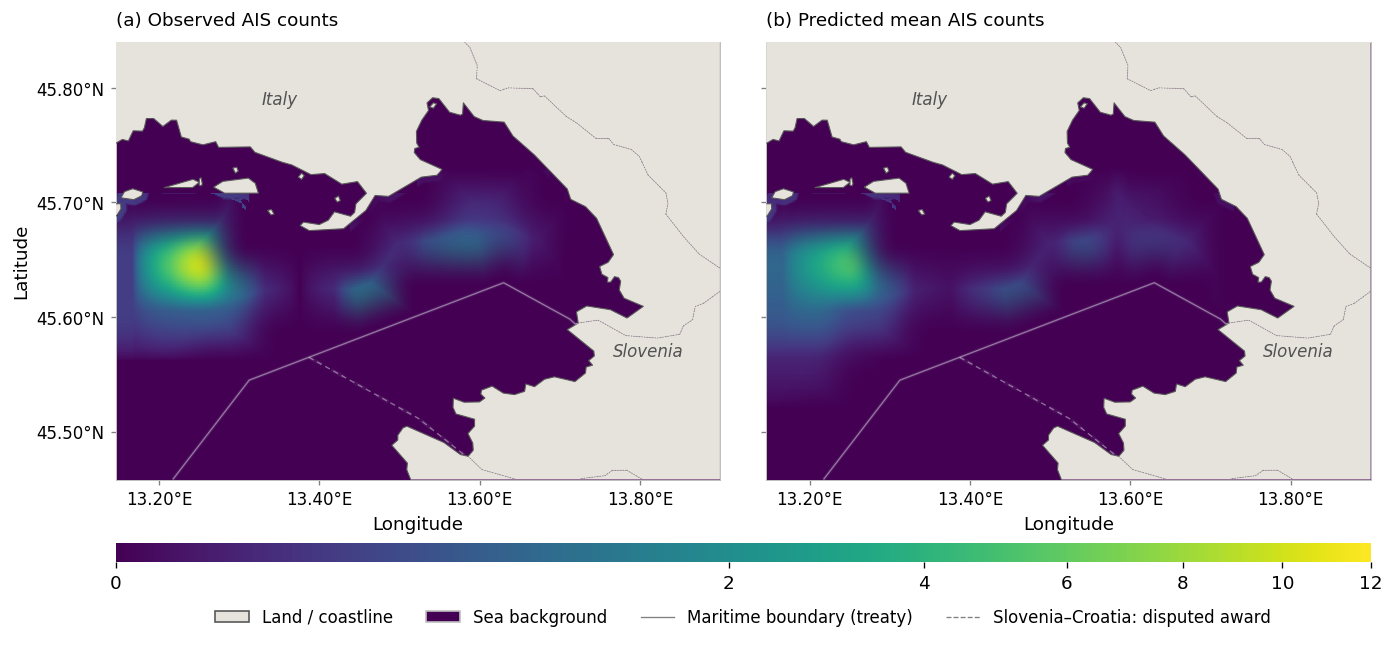

Rendered both previews in 5.51 s.


In [26]:
colorbar_orientation = "horizontal"  # "vertical": right of panel (b); "horizontal": below the maps.

show_line = False  # False hides the dashed model-coverage boundary.
show_maritime_lines = True  # Independent of show_line (the grid-support boundary).
mask_slovenian_waters = True  # Display-only: keep Slovenian waters as sea background.

mask_croatian_waters = True  # Display-only: keep Croatian waters as sea background.

plot_residuals = False  # False plots only observed and predicted counts; True adds residuals.

smooth_sea_edges = True  # False uses sharp edges, retaining the clear maritime-border margin.
sea_edge_fade_km = 6.0  # Inward transition width; larger = softer/wider.

# Colour contrast: 1 = linear; below 1 strengthens faint values; above 1 softens them.
count_gamma = 0.4      # Standard = 1. Try 0.6 to make low observed/predicted counts brighter.
residual_gamma = 1.0   # Standard = 1. Try 0.5 for stronger blue/red.
count_vmax = None       # Automatic shared maximum; a fixed value must cover all counts.
residual_vmax = None    # Automatic symmetric limits; a fixed value must cover all residuals.

STYLE = dict(
    colorbar_orientation=colorbar_orientation,
    figsize=(16, 5.5), preview_dpi=120, font_size=11,
    count_cmap="viridis", residual_cmap="RdBu_r", count_vmax=count_vmax,
    count_gamma=count_gamma, residual_gamma=residual_gamma, residual_vmax=residual_vmax,
    coast_color="0.35", land_color="#e6e3dc", sea_color="count_min",
    residual_sea_color="residual_zero",  # Match the residual colormap at zero exactly.
    support_color="0.45", show_line=show_line,
    show_country_labels=True, show_country_borders=True,
    show_maritime_lines=show_maritime_lines,
    mask_slovenian_waters=mask_slovenian_waters,
    mask_croatian_waters=mask_croatian_waters,
    smooth_sea_edges=smooth_sea_edges, sea_edge_fade_km=sea_edge_fade_km,
    maritime_color="#d8dce2", residual_maritime_color="0.45",
    maritime_linewidth=0.8, maritime_alpha=0.5,
    show_support=False, support_size=12, show_grid=False,
    panel_titles=["(a) Observed AIS counts", "(b) Predicted mean AIS counts",
                  "(c) Prediction residuals\n(predicted − observed)"],
)

started = perf_counter()
if "fig" in globals():
    plt.close(fig)
fig, axes = draw_map(prepared, STYLE)
if plot_residuals:
    display(fig) # Plot two pics + residuals 
plt.close(fig)  # Prevent duplicate automatic inline output; fig remains available for export.
                # A separate two-map figure from the same cell, using the same date, surfaces,
                # colormap and count limits as the three-panel figure above.
COMPARISON_STYLE = dict(STYLE, figsize=(11.5, 5.5))
if "comparison_fig" in globals():
    plt.close(comparison_fig)
comparison_fig, comparison_axes = draw_map(prepared, COMPARISON_STYLE, include_residual=False)
display(comparison_fig)
plt.close(comparison_fig)
print(f"Rendered both previews in {perf_counter() - started:.2f} s.")

## Aggregated interval comparison
Set **both** `INTERVAL_START` and `INTERVAL_END` below (inclusive) within **May 1–28** or **November 1–28, 2025**. Defaults cover **May 1–7**. Intervals can cross weekly boundaries: each day uses its corresponding weekly model's saved prediction.

For each retained cell, **sum the original observed daily counts and predicted daily means over the interval, then interpolate those totals** using the same settings as the daily comparison. The predicted total is an expected count summed across days; these totals do not represent unique vessels across the interval. Both maps share one count scale; the cell prints both endpoints and the number of days below the preview.

Every requested day and spatial cell must be present, with exactly one source run per day. Missing days are never treated as zero. The preview reports all source runs and retains their provenance in the aggregated rows. It has its own variables and leaves the daily selection and export unchanged.

This comparison reuses the same GIS geography and retained-support mask as the single-day maps.


In [23]:
import sys; sys.exit("Esecuzione interrotta manualmente.")

SystemExit: Esecuzione interrotta manualmente.

/home/samuele/projects/AIPS/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


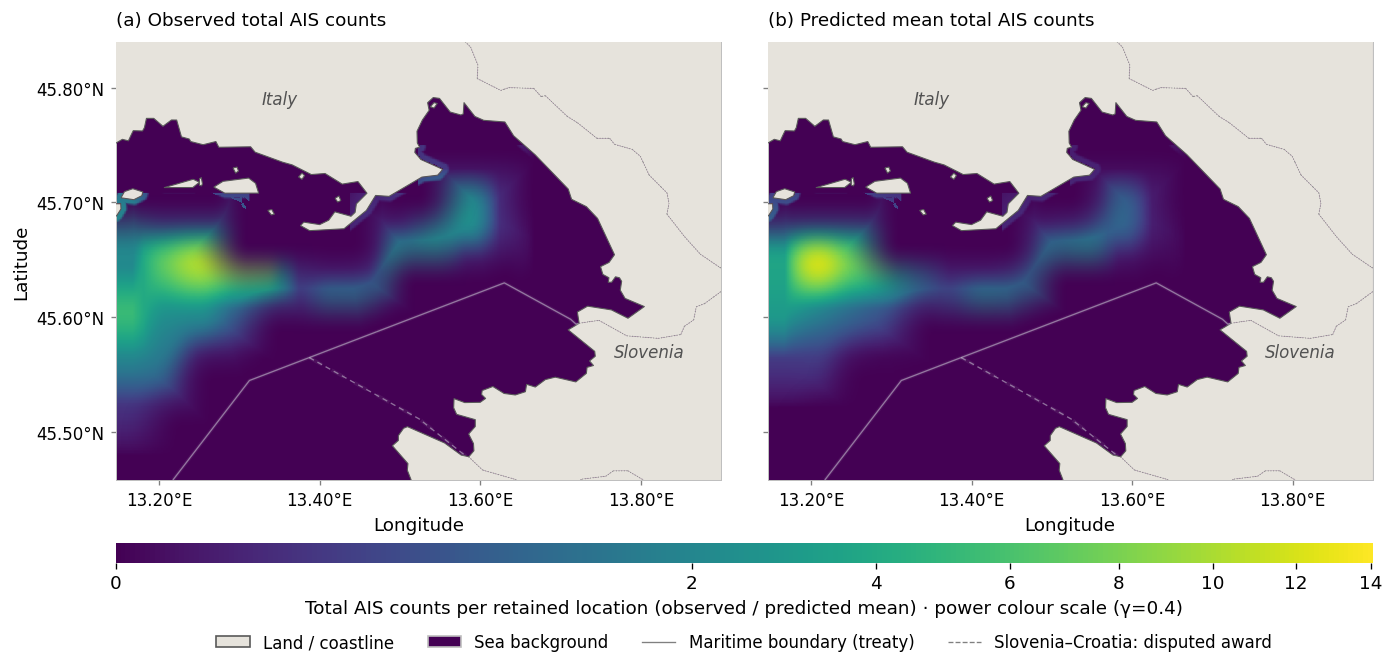

Interval: 2025-05-01 to 2025-05-07 (7 days, inclusive)
Source runs: 2024+2025_2025_may_01_07_20261002-093859
Summed 7 days across 49 cells: observed=71, predicted=52.217.


In [ ]:
INTERVAL_START = "2025-05-01"
INTERVAL_END = "2025-05-07"

print("ATTENTION: the plot design is not updated to the single day (which has been improved)")

def prepare_interval_map(data, geography, method, start, end, **surface_settings):
    start, end = pd.Timestamp(start).normalize(), pd.Timestamp(end).normalize()
    if pd.isna(start) or pd.isna(end) or start > end:
        raise ValueError("Provide valid interval endpoints with start <= end.")
    days = pd.date_range(start, end, freq="D")
    selected = data.loc[(data["method"] == method) & data["date"].between(start, end)].copy()
    missing = days.difference(pd.DatetimeIndex(selected["date"].unique()))
    if len(missing):
        raise ValueError("The interval contains days without saved predictions: "
                         + ", ".join(missing.strftime("%Y-%m-%d")))
    if not selected.groupby("date")["source_run"].nunique().eq(1).all():
        raise ValueError("Each interval day must use exactly one weekly run.")
    cell_columns = ["longitude", "latitude"]
    if selected.duplicated(["date", *cell_columns]).any():
        raise ValueError("Duplicate cell-day rows cannot be aggregated.")
    coverage = selected.groupby(cell_columns)["date"].nunique()
    if not coverage.eq(len(days)).all():
        raise ValueError("Every retained cell must have a prediction and observation on every interval day.")
    totals = selected.groupby(cell_columns, as_index=False).agg(
        y_true=("y_true", "sum"), y_pred=("y_pred", "sum"),
        source_run=("source_run", lambda values: "; ".join(sorted(values.unique()))),
        source_csv=("source_csv", lambda values: "; ".join(sorted(values.unique()))),
    )
    totals["method"] = method
    # prepare_map uses a date to select rows; here all rows represent one interval.
    totals["date"] = start
    result = prepare_map(totals, geography, method, start, **surface_settings)
    result["interval_start"] = start.strftime("%Y-%m-%d")
    result["interval_end"] = end.strftime("%Y-%m-%d")
    result["n_days"] = len(days)
    result["aggregation"] = "sum of original cell-day values before interpolation"
    result["date"] = f"{result['interval_start']} to {result['interval_end']} ({len(days)} days, inclusive)"
    result["rows"]["interval_start"] = result["interval_start"]
    result["rows"]["interval_end"] = result["interval_end"]
    result["rows"] = result["rows"].drop(columns="date")
    return result


interval_prepared = prepare_interval_map(
    predictions, geography, METHOD, INTERVAL_START, INTERVAL_END, **SURFACE
)
INTERVAL_STYLE = dict(
    COMPARISON_STYLE,
    count_label="Total AIS counts per retained location (observed / predicted mean)",
    count_vmax=None,  # Auto-scale the totals; daily count limits need not fit this interval.
    panel_titles=["(a) Observed total AIS counts", "(b) Predicted mean total AIS counts"],
)
if "interval_fig" in globals():
    plt.close(interval_fig)
interval_fig, interval_axes = draw_map(interval_prepared, INTERVAL_STYLE, include_residual=False)
display(interval_fig)
plt.close(interval_fig)
print("Interval:", interval_prepared["date"])
print("Source runs:", interval_prepared["rows"]["source_run"].iloc[0])
print(f"Summed {interval_prepared['n_days']} days across {len(interval_prepared['rows'])} cells: "
      f"observed={interval_prepared['rows']['y_true'].sum():g}, "
      f"predicted={interval_prepared['rows']['y_pred'].sum():.3f}.")

## Export
Set `SAVE_FIGURE=True` and rerun this cell when ready. The figure is rebuilt from the current `prepared` data and `STYLE`, then saved with a common filename in a dedicated design folder. Set `EXPORT_TAG` to keep multiple variants; reusing a tag replaces that variant's files. PNG is convenient for review, PDF/SVG preserve vector text and the outline with an embedded raster surface.

The companion CSV contains the original cell counts and **raw** residuals; the JSON records sources, interpolation, style, and actual colour limits. The caption describes the displayed residual correctly. No existing experiment plots are overwritten.

In [ ]:
SAVE_FIGURE = False
EXPORT_TAG = "v01"
EXPORT_FORMATS = ("png", "pdf", "svg")
EXPORT_DPI = 300

if SAVE_FIGURE:
    if not EXPORT_TAG or any(c not in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-" for c in EXPORT_TAG):
        raise ValueError("Use letters, numbers, underscores, and hyphens in EXPORT_TAG.")
    if not set(EXPORT_FORMATS) <= {"png", "pdf", "svg"}:
        raise ValueError("Choose export formats from png, pdf, svg.")
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"gulf_map_{prepared['method']}_{prepared['date']}_{EXPORT_TAG}"
    export_fig, export_axes = draw_map(prepared, STYLE)
    try:
        for suffix in EXPORT_FORMATS:
            path = EXPORT_DIR / f"{stem}.{suffix}"
            export_fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", facecolor="white")
            print(path)
        count_norm = export_axes[0].images[0].norm
        residual_norm = export_axes[2].images[0].norm
        metadata = {
            "method": prepared["method"], "date": prepared["date"],
            "source_csvs": sorted(prepared["rows"].source_csv.unique().tolist()),
            "source_runs": sorted(prepared["rows"].source_run.unique().tolist()),
            "source_windows": sorted(prepared["rows"].source_window.unique().tolist()),
            "training_cutoffs": sorted(prepared["rows"].train_end.unique().tolist()),
            "seed": 1,
            "coordinate_conversion": "inverse saved plotting metadata, then match to original grid within 0.0001 degrees",
            "grid_file": str(GRID_FILE.relative_to(PROJECT_ROOT)),
            "gis_file": str(GIS_FILE.relative_to(PROJECT_ROOT)),
            "geography_source": GEOGRAPHY_SOURCE,
            "maritime_source": MARITIME_SOURCE if STYLE.get("show_maritime_lines", True) else None,
            "italian_edge_smoothing_mask": MARITIME_SOURCE["italian_edge_smoothing_mask"] if STYLE.get("smooth_sea_edges", False) else None,
            "map_extent": prepared["geography"]["extent"],
            "croatian_display_mask": MARITIME_SOURCE["croatian_display_mask"] if STYLE.get("mask_croatian_waters", True) else None,
            "slovenian_display_mask": MARITIME_SOURCE["slovenian_display_mask"] if STYLE.get("mask_slovenian_waters", True) else None,
            "support_definition": "union of retained cell footprints intersected with GIS water and map extent",
            "surface": prepared["surface_settings"], "style": STYLE,
            "count_limits": [count_norm.vmin, count_norm.vmax],
            "residual_limits": [residual_norm.vmin, residual_norm.vmax],
            "residual_definition": "displayed predicted surface minus displayed observed surface",
            "raw_residual_definition": "saved y_pred minus saved y_true",
            "export_dpi": EXPORT_DPI,
            "versions": {"matplotlib": mpl.__version__, "numpy": np.__version__, "pandas": pd.__version__},
        }
        (EXPORT_DIR / f"{stem}_settings.json").write_text(json.dumps(metadata, indent=2) + "\n")
        prepared["rows"].to_csv(EXPORT_DIR / f"{stem}_cells.csv", index=False)
        label = METHOD_LABELS.get(prepared["method"], prepared["method"])
        caption = (
            f"Spatial prediction example in the Gulf of Trieste for {prepared['date']} ({label}). "
            "(a) Observed AIS counts, (b) predicted mean AIS counts, and (c) prediction residuals "
            "(displayed predicted surface minus displayed observed surface). Observed and predicted "
            "maps share one colour scale; residuals use a diverging scale centred at zero. "
            "Maps share longitude–latitude coordinates, geographic extent, GIS coastline and retained-grid support mask. "
            + SUPPORT_NOTE + " Geographic context: Eurostat GISCO Countries 2024, 1:1 million. © EuroGeographics for the administrative boundaries. " +
            "The smooth surfaces visualize counts defined on the retained spatial cells, not continuous vessel density."
        )
        if STYLE.get("count_gamma", 1.0) != 1 or STYLE.get("residual_gamma", 1.0) != 1:
            caption += (f" Colour scales use power normalization (counts γ={STYLE.get('count_gamma', 1.0):g}; "
                        f"residuals γ={STYLE.get('residual_gamma', 1.0):g}, symmetric about zero); "
                        "colourbar labels remain in count units.")
        if STYLE.get("mask_slovenian_waters", True):
            caption += (" Slovenian waters (Marine Regions, MRGID 5692) are masked for display only; "
                        "sea background in this area does not represent zero counts. Original cell values are retained.")
        if STYLE.get("mask_croatian_waters", True):
            caption += " Croatian waters (Marine Regions, MRGID 5673) are masked for display only; original cell values are retained."
        if STYLE.get("mask_slovenian_waters", True) or STYLE.get("mask_croatian_waters", True):
            caption += " A 100 m display-only clear margin removes heatmap colour beneath the enabled Italian sea-border lines."
        if STYLE.get("smooth_sea_edges", False):
            caption += (f" Offshore grid edges in Italian waters are opacity-feathered inward over {STYLE['sea_edge_fade_km']:g} km "
                        "for display only, using Marine Regions (VLIZ), MRGID 5682, CC BY 4.0. "
                        "The offshore fade protects coastlines; enabled Italian sea borders fade to background. Blended margin colours are not quantitative values. "
                        "Raw values and colour scales are unchanged.")
        if STYLE.get("show_maritime_lines", True):
            caption += (" Maritime lines: Marine Regions (VLIZ), World Maritime Boundaries v12 (2023), CC BY 4.0. "
                        "Italy's bilateral divisions use treaty lines; the Slovenia–Croatia line follows the "
                        "2017 arbitral award and is disputed by Croatia. Junction-regime limits are not shown.")
        (EXPORT_DIR / f"{stem}_caption.txt").write_text(caption + "\n")
        display(Markdown(caption))
    finally:
        plt.close(export_fig)
else:
    print("Preview only. Set SAVE_FIGURE=True to export the current design.")

Preview only. Set SAVE_FIGURE=True to export the current design.
